[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb02_llm_regimes_and_memory.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb02 — Does the LLM read regimes, or remember them?

Phase 4 of `llm-regime-allocator`. Every LLM answer here is replayed from the committed response cache (`results/llm_cache/`); this notebook makes **no API calls** and fits nothing except the no-LLM baselines already in `results/baselines/`.

**Task (H1).** At each month-end D (2007-12 → 2026-05) the model reads a point-in-time macro + market context pack and returns probabilities for the growth × inflation regime over the **next 3 months**: Goldilocks, Reflation, Stagflation, Risk_Off. 217 months have a published outcome.

**Scores.** Hit rate (top call correct), multi-class Brier (0 = perfect, uniform 25% each = 0.75), log-loss (uniform = ln 4 = 1.386). Confidence intervals: moving-block bootstrap (6-month blocks), 95%, on the paired per-month difference.

**The story in five steps:** first look → give it the date → can it guess the date? → blind the data → verdict on the months it cannot date.

In [2]:
import sys, json, glob
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lra.evaluation import R, score, brier_per_obs, block_bootstrap_ci, uniform, hard
from lra.llm.blind import blind_features
from lra.llm.prompts import render_data, render_blinded
B, L = Path('../results/baselines'), Path('../results/llm')
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']   # fixed categorical order (nb01)
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': MUTED, 'text.color': INK})
rd = lambda p: pd.read_csv(p, parse_dates=['date'], index_col='date')
reg, fair, feat = rd(B / 'regimes.csv'), rd(B / 'regimes_fair.csv'), rd(B / 'features.csv')
y = reg['realised_forward'].dropna()
son = {v: rd(L / f'claude_sonnet/{v}_run0.csv') for v in ('anonymized', 'dated', 'date_only', 'blinded')}
probe = {k: rd(L / f'claude_sonnet/{k}_run0.csv') for k in ('date_probe', 'date_probe_blinded')}
cols = lambda df, p: df[[f'{p}_{k}' for k in R]].set_axis(R, axis=1)
fc = {'uniform 25%': uniform(reg.index),
      'climatology (point-in-time)': cols(fair, 'climatology'),
      'rule (persistence)': hard(reg['rule']),
      'ML logit, raw pack': cols(reg, 'logit'), 'ML GBT, raw pack': cols(reg, 'gbt'),
      'ML logit, blinded pack': cols(fair, 'logit_blinded'), 'ML GBT, blinded pack': cols(fair, 'gbt_blinded'),
      'Haiku 4.5, raw pack': rd(L / 'claude_haiku/anonymized_run0.csv')[R],
      'Llama 3.1 8B, raw pack': rd(L / 'llama8b/anonymized_run0.csv')[R],
      'Sonnet 5.5, raw pack': son['anonymized'][R], 'Sonnet 5.5, raw pack + date': son['dated'][R],
      'Sonnet 5.5, date only': son['date_only'][R], 'Sonnet 5.5, blinded pack': son['blinded'][R]}
def table(names, idx=y.index):
    yy = y.loc[idx]
    t = pd.DataFrame({n: score(fc[n], yy) for n in names}).T.round(3)
    return t.astype({'n': int})

## 1. First look: the raw context pack, no date, no tickers

The prompt contains the latest published macro values (levels, 3m/12m changes, 36m z-scores) and asset-class returns, labelled by role ("US large-cap equity"), never by ticker or date.

In [3]:
table(['uniform 25%', 'climatology (point-in-time)', 'rule (persistence)', 'ML logit, raw pack', 'ML GBT, raw pack',
       'Haiku 4.5, raw pack', 'Llama 3.1 8B, raw pack', 'Sonnet 5.5, raw pack'])

,n,hit_rate,brier,log_loss
uniform 25%,217,0.189,0.750,1.386
climatology (point-in-time),217,0.161,0.770,1.427
rule (persistence),217,0.332,1.099,2.056
"ML logit, raw pack",217,0.373,0.861,1.761
"ML GBT, raw pack",217,0.323,0.880,1.730
"Haiku 4.5, raw pack",217,0.244,0.864,1.572
"Llama 3.1 8B, raw pack",217,0.244,0.874,1.681
"Sonnet 5.5, raw pack",217,0.369,0.702,1.324


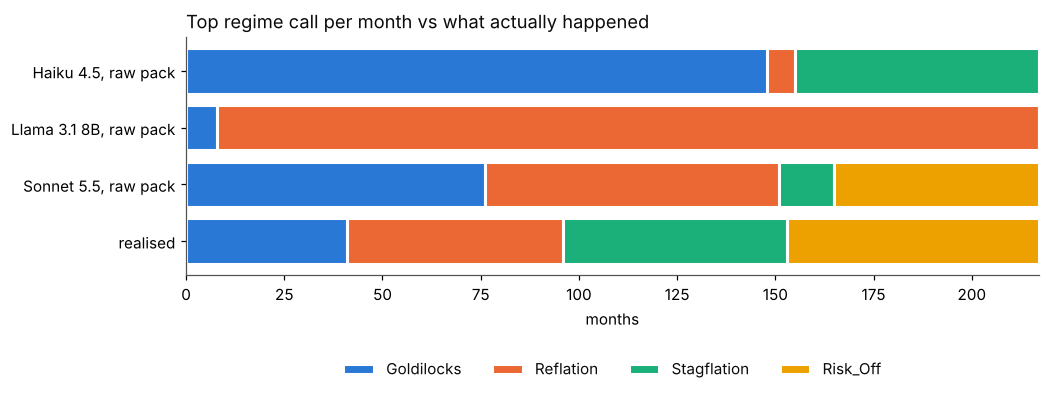

,Goldilocks,Reflation,Stagflation,Risk_Off
"Haiku 4.5, raw pack",148,7,62,0
"Llama 3.1 8B, raw pack",8,209,0,0
"Sonnet 5.5, raw pack",76,75,14,52
realised,41,55,57,64


In [4]:
calls = pd.DataFrame({m: fc[m].loc[y.index].idxmax(axis=1).value_counts() for m in
                      ['Haiku 4.5, raw pack', 'Llama 3.1 8B, raw pack', 'Sonnet 5.5, raw pack']}).T
calls.loc['realised'] = y.value_counts()
calls = calls[R].fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(10, 2.8))
left = np.zeros(len(calls))
for k, c in zip(R, C):
    ax.barh(calls.index, calls[k], left=left, color=c, label=k, edgecolor='white', linewidth=2)
    left += calls[k].values
ax.invert_yaxis(); ax.grid(False); ax.set_xlabel('months')
ax.legend(ncol=4, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.3))
ax.set_title('Top regime call per month vs what actually happened', loc='left'); plt.show()
calls

**Reading.** Sonnet is the only forecaster better than uniform on Brier and log-loss, with a hit rate matching the best ML model — but its Brier gain is not significant (CI below). Haiku and Llama collapse onto one regime (Llama: Reflation almost every month), so they carry no information and Llama cannot serve as the pre-cutoff control we had planned.

In [5]:
d = brier_per_obs(fc['Sonnet 5.5, raw pack'], y) - brier_per_obs(fc['uniform 25%'], y)
print(f'Sonnet raw - uniform Brier: {d.mean():+.3f}  95% CI {np.round(block_bootstrap_ci(d), 3)}')

Sonnet raw - uniform Brier: -0.048  95% CI [-0.111  0.013]


## 2. Give it the date

Same data, plus the as-of date in the prompt (`dated`). A second ablation gives **only** the month and no data (`date_only`). If skill comes from reading the data, the date should add nothing.

In [6]:
table(['uniform 25%', 'Sonnet 5.5, date only', 'Sonnet 5.5, raw pack', 'Sonnet 5.5, raw pack + date'])

,n,hit_rate,brier,log_loss
uniform 25%,217,0.189,0.750,1.386
"Sonnet 5.5, date only",217,0.221,0.747,1.380
"Sonnet 5.5, raw pack",217,0.369,0.702,1.324
"Sonnet 5.5, raw pack + date",217,0.470,0.651,1.227


dated - raw Brier: -0.051  95% CI [-0.07  -0.036]
date changes the top call in 54 months: dated right 28, raw right 6


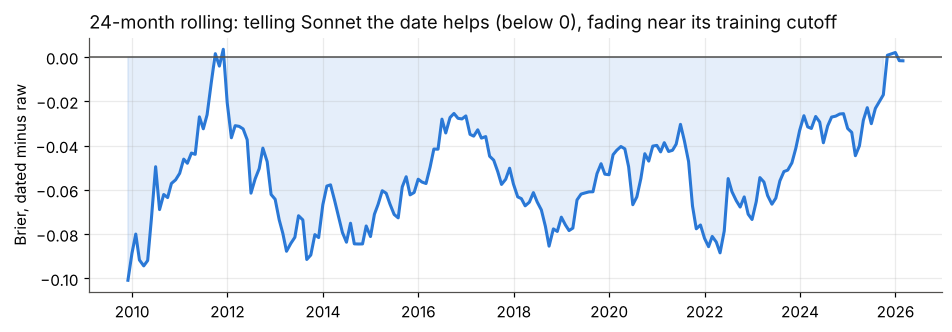

In [7]:
a, d_ = fc['Sonnet 5.5, raw pack'], fc['Sonnet 5.5, raw pack + date']
diff = brier_per_obs(d_, y) - brier_per_obs(a, y)
print(f'dated - raw Brier: {diff.mean():+.3f}  95% CI {np.round(block_bootstrap_ci(diff), 3)}')
ca, cd = a.loc[y.index].idxmax(axis=1), d_.loc[y.index].idxmax(axis=1)
sw = y.index[ca != cd]
print(f'date changes the top call in {len(sw)} months: dated right {(cd[sw] == y[sw]).sum()}, '
      f'raw right {(ca[sw] == y[sw]).sum()}')
roll = diff.rolling(24).mean()
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(roll.index, roll, color=C[0])
ax.axhline(0, color=MUTED, linewidth=1)
ax.fill_between(roll.index, roll, 0, where=roll < 0, color=C[0], alpha=0.12)
ax.set_ylabel('Brier, dated minus raw')
ax.set_title('24-month rolling: telling Sonnet the date helps (below 0), fading near its training cutoff', loc='left')
plt.show()

**Reading.** With no data, Sonnet refuses to guess (≈ 25% each), so `date_only` is uninformative. But adding the date to the data improves every score **significantly**, and when the date changes its call, the new call is right far more often than the old one. The benefit disappears near the model's training cutoff, where it has seen the least about what happened next. That is the signature of remembered outcomes, not better reasoning.

## 3. Can it work out the date anyway?

Date-recovery probe: same raw pack, no date, and the only question is *which month is this?* (answer: year + month, between 2007 and 2026).

In [8]:
def probe_stats(p):
    e = p['error_months'].abs()
    return pd.Series({'exact month': (e == 0).mean(), 'within 6m': (e <= 6).mean(),
                      'within 12m': (e <= 12).mean(), 'mean abs error (months)': e.mean()})
pd.DataFrame({'raw pack': probe_stats(probe['date_probe']),
              'blinded pack': probe_stats(probe['date_probe_blinded'])}).round(3)

,raw pack,blinded pack
exact month,0.842,0.135
within 6m,1.000,0.378
within 12m,1.000,0.495
mean abs error (months),0.216,45.550


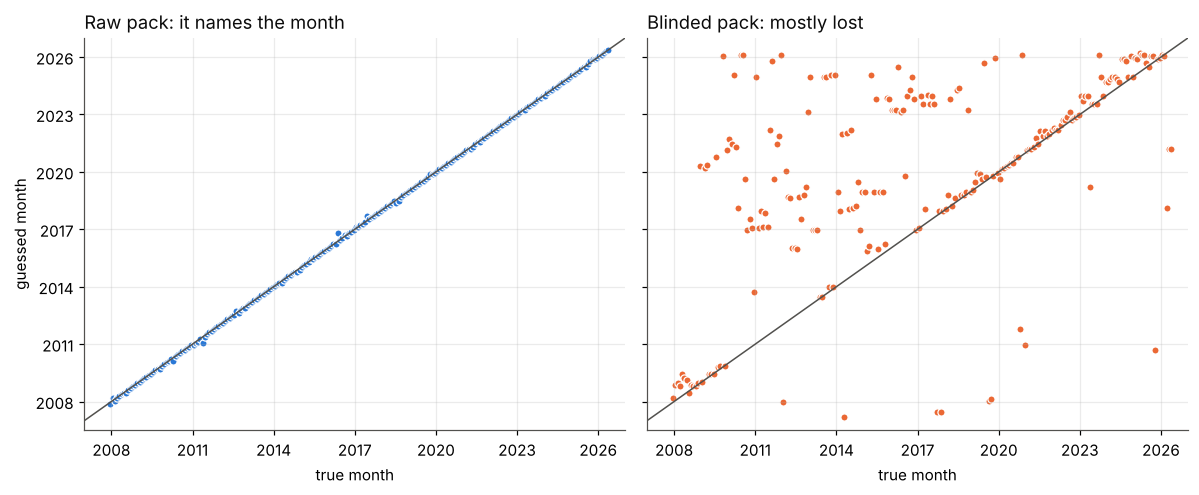

In [9]:
def to_year(idx, yr, mo): return yr + (mo - 0.5) / 12
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for ax, (k, title), c in zip(axes, [('date_probe', 'Raw pack: it names the month'),
                                    ('date_probe_blinded', 'Blinded pack: mostly lost')], C[:2]):
    p = probe[k]
    t = p.index.year + (p.index.month - 0.5) / 12
    g = to_year(p.index, p['guess_year'], p['guess_month'])
    ax.plot([2007, 2027], [2007, 2027], color=MUTED, linewidth=1)
    ax.scatter(t, g, s=22, color=c, edgecolor='white', linewidth=0.8)
    ax.set_xlim(2007, 2027); ax.set_ylim(2006.5, 2027); ax.set_title(title, loc='left')
    ax.set_xticks(range(2008, 2027, 3)); ax.set_yticks(range(2008, 2027, 3))
    ax.set_xlabel('true month')
axes[0].set_ylabel('guessed month'); plt.tight_layout(); plt.show()

In [10]:
rec = next(json.load(open(f)) for f in glob.glob('../results/llm_cache/claude-sonnet-5-5/*/*.json')
           if (r := json.load(open(f))).get('variant') == 'date_probe' and r['decision_date'] == '2013-05-31')
print(json.loads(rec['text'][rec['text'].find('{'):])['cues'])

['Unemployment 7.5% and 10-year yield 2.13% after a sharp rise, consistent with the 2013 taper tantrum', 'Gold down about 12% over 3 months and 20+ year Treasuries -7.7% in one month', 'Headline CPI about 1.1% YoY and US equities near highs with VIX about 14.5']


**Reading.** Removing the date and tickers did **not** anonymise anything: from levels such as the policy rate, the 10-year yield and unemployment, Sonnet names the exact month most of the time. So the raw-pack result in section 1 is not clean either — the model always knew where it was.

## 4. Blind the data

Every figure becomes a z-score versus **its own last 36 months**, rounded to 0.5 and capped at ±3. No levels, no percentages. The economics survive ("inflation high and rising versus its recent past, bonds selling off"); the timestamp should not. The transform uses trailing windows only and is unit-tested for point-in-time invariance. Same month, before and after:

In [11]:
d0 = pd.Timestamp('2013-05-31')
raw_lines = render_data(feat.loc[d0]).splitlines()
bl_lines = render_blinded(blind_features(feat).loc[d0]).splitlines()
keep = ('indicator |', 'asset |', 'Unemployment rate', '10-year Treasury yield', 'Headline CPI', 'US Treasuries 20y+', 'Gold')
pick = lambda lines: '\n'.join(l for l in lines if l.startswith(keep))
print('RAW (excerpt)'); print(pick(raw_lines))
print('\nBLINDED (excerpt)'); print(pick(bl_lines))

RAW (excerpt)
indicator | units | latest | 3m chg | 12m chg | z
Unemployment rate | % | +7.50 | -0.40 | -0.60 | -1.69
Headline CPI | YoY % | +1.11 | -0.47 | -1.16 | -1.23
10-year Treasury yield | % | +2.13 | +0.24 | +0.54 | -0.29
asset | 1m | 3m | 6m | 12m | vol 6m | drawdown 12m
US Treasuries 20y+ | -7.7% | -3.3% | -7.3% | -4.6% | +12.7% | -11.5%
Gold | -5.1% | -12.1% | -19.6% | -11.3% | +20.1% | -22.9%

BLINDED (excerpt)
indicator | level | 3m change | 12m change
Unemployment rate | -1.5 | -1.0 | +0.0
Headline CPI | -1.0 | -0.5 | -1.0
10-year Treasury yield | -0.5 | +1.0 | +2.0
asset | 1m | 3m | 6m | 12m | vol 6m | drawdown 12m
US Treasuries 20y+ | -2.0 | -1.0 | -1.0 | -1.5 | -1.0 | -1.5
Gold | -1.0 | -2.0 | -2.5 | -1.5 | +0.5 | -2.5


In [12]:
p = probe['date_probe_blinded']
e = p['error_months'].abs()
by = e.groupby(pd.cut(p.index.year, [2006, 2012, 2019, 2026], labels=['2007-12', '2013-19', '2020-26']), observed=True)
pd.DataFrame({'months': by.size(), 'mean abs error': by.mean().round(1), 'within 6m': by.apply(lambda s: (s <= 6).mean()).round(2)})

,months,mean abs error,within 6m
2007-12,61,74.2,0.21
2013-19,84,53.9,0.27
2020-26,77,13.8,0.62


**Reading.** Blinding removes the date for most of the sample: 2007–2012 is at random-guess accuracy, 2013–2019 nearly so. The recent period (COVID, the 2022 inflation shock) stays recognisable even as z-scores. Rather than blinding harder, the probe gives us a split: months Sonnet **cannot** date are the clean test.

## 5. Verdict: skill on the blinded pack

Compared with no-LLM forecasters that see **exactly the same information** (walk-forward logit and gradient boosting on the blinded features) and with the honest no-skill baselines.

In [13]:
names = ['uniform 25%', 'climatology (point-in-time)', 'ML logit, blinded pack', 'ML GBT, blinded pack',
         'Sonnet 5.5, raw pack', 'Sonnet 5.5, blinded pack', 'Sonnet 5.5, raw pack + date']
err = probe['date_probe_blinded']['error_months'].loc[y.index].abs()
groups = {'all months': y.index, 'cannot date (>12m off)': y.index[err > 12], 'can date (≤12m)': y.index[err <= 12]}
tb = pd.concat({g: table(names, idx)['brier'] for g, idx in groups.items()}, axis=1)
tb.loc['months (n)'] = [len(i) for i in groups.values()]
tb.rename_axis('Brier (lower is better)')

,all months,cannot date (>12m off),can date (≤12m)
Brier (lower is better),,,
uniform 25%,0.750,0.750,0.750
climatology (point-in-time),0.770,0.773,0.767
"ML logit, blinded pack",0.884,0.914,0.854
"ML GBT, blinded pack",0.871,0.954,0.786
"Sonnet 5.5, raw pack",0.702,0.725,0.678
"Sonnet 5.5, blinded pack",0.668,0.699,0.637
"Sonnet 5.5, raw pack + date",0.651,0.678,0.623
months (n),217.000,109.000,108.000


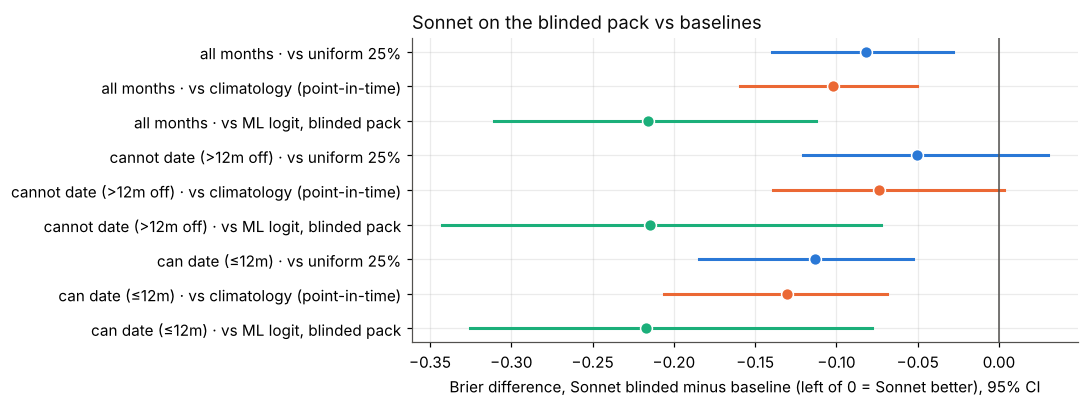

,months,vs,n,diff,lo,hi
0,all months,uniform 25%,217,-0.082,-0.139,-0.028
1,all months,climatology (point-in-time),217,-0.102,-0.159,-0.051
2,all months,"ML logit, blinded pack",217,-0.216,-0.311,-0.113
3,cannot date (>12m off),uniform 25%,109,-0.051,-0.120,0.030
4,cannot date (>12m off),climatology (point-in-time),109,-0.074,-0.139,0.003
5,cannot date (>12m off),"ML logit, blinded pack",109,-0.215,-0.342,-0.072
6,can date (≤12m),uniform 25%,108,-0.113,-0.185,-0.053
7,can date (≤12m),climatology (point-in-time),108,-0.130,-0.206,-0.069
8,can date (≤12m),"ML logit, blinded pack",108,-0.217,-0.325,-0.078


In [14]:
rows = []
for g, idx in groups.items():
    yy = y.loc[idx]
    for ref in ['uniform 25%', 'climatology (point-in-time)', 'ML logit, blinded pack']:
        dd = (brier_per_obs(fc['Sonnet 5.5, blinded pack'], yy) - brier_per_obs(fc[ref], yy)).reset_index(drop=True)
        lo, hi = block_bootstrap_ci(dd)
        rows.append({'months': g, 'vs': ref, 'n': len(yy), 'diff': dd.mean(), 'lo': lo, 'hi': hi})
ci = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 3.8))
ypos = np.arange(len(ci))[::-1]
colors = {'uniform 25%': C[0], 'climatology (point-in-time)': C[1], 'ML logit, blinded pack': C[2]}
for yp, (_, r) in zip(ypos, ci.iterrows()):
    ax.plot([r.lo, r.hi], [yp, yp], color=colors[r.vs], linewidth=2)
    ax.scatter(r['diff'], yp, s=60, color=colors[r.vs], edgecolor='white', zorder=3)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_yticks(ypos, [f"{r.months} · vs {r.vs}" for _, r in ci.iterrows()])
ax.set_xlabel('Brier difference, Sonnet blinded minus baseline (left of 0 = Sonnet better), 95% CI')
ax.set_title('Sonnet on the blinded pack vs baselines', loc='left'); plt.tight_layout(); plt.show()
ci.round(3)

## 6. Robustness checks (added after an external adversarial review)

**(a) Is "cannot date" just a period split?** The months Sonnet cannot date are mostly 2008–2019, the ones it can date mostly 2020+. Within the same era, and with year fixed effects:

In [15]:
pd.read_csv('../results/h1/date_probe_era.csv').round(3)

,era,bucket,n,brier_minus_uniform,ci_lo,ci_hi
0,2007-2019,can date,47,-0.139,NaN,NaN
1,2007-2019,cannot date,98,-0.047,NaN,NaN
2,2020-2026,can date,61,-0.094,NaN,NaN
3,2020-2026,cannot date,11,-0.084,NaN,NaN
4,"all, year fixed effects",datable minus cannot-date,217,0.037,-0.076,0.134


Within 2007–2019 the datable months still show a larger gain, but comparing months **within the same year** the difference disappears (CI spans zero). The split cannot separate memory from period and regime difficulty, so it is evidence, not proof, that the edge does not depend on recall.

**(b) Which vintage scores the outcome?** The primary target uses the macro vintage at data end. Scoring each month with the *first* release that makes its regime knowable changes 33 of 217 labels:

In [16]:
sc = pd.read_csv('../results/h1/scores.csv')
keep = ['uniform', 'climatology', 'ml_logit', 'ml_logit_blinded', 'claude_sonnet:anonymized',
        'claude_sonnet:blinded', 'claude_sonnet:dated']
sc[sc.forecaster.isin(keep) & sc.window.isin(['full', 'first-release labels'])]\
  .pivot(index='forecaster', columns='window', values='brier').loc[keep].round(3)

window,first-release labels,full
forecaster,,
uniform,0.750,0.750
climatology,0.765,0.770
ml_logit,0.822,0.861
ml_logit_blinded,0.854,0.884
claude_sonnet:anonymized,0.670,0.702
claude_sonnet:blinded,0.646,0.668
claude_sonnet:dated,0.627,0.651


Every forecaster scores slightly better on first-release labels and the ranking is unchanged.

**(c) CFNAI before 2011-05 uses revised values** (its ALFRED vintages start then; flagged since Phase 1). Revisions are moderate (3-month average: mean absolute revision 0.18 vs a standard deviation of 0.78, correlation 0.94); the broad dollar index, hybrid until 2019, revises negligibly (YoY: 0.17 pp vs 6 pp). Dropping CFNAI leaves the ML baselines essentially unchanged:

In [17]:
sc[sc.forecaster.isin(['ml_logit', 'ml_logit_nocfnai', 'ml_logit_blinded', 'ml_logit_blinded_nocfnai']) &
   (sc.window == 'full')][['forecaster', 'hit_rate', 'brier', 'log_loss']].round(3)

,forecaster,hit_rate,brier,log_loss
4,ml_logit,0.373,0.861,1.761
8,ml_logit_blinded,0.304,0.884,1.708
14,ml_logit_nocfnai,0.373,0.859,1.742
16,ml_logit_blinded_nocfnai,0.327,0.882,1.716


For Sonnet, the 41 affected months (2007-12 → 2011-04) were re-asked with the CFNAI line removed (`blinded_nocfnai`, 41 calls):

In [18]:
pd.read_csv('../results/h1/nocfnai_check.csv').round(3)

,forecaster,n,hit_rate,brier,log_loss,ci_lo,ci_hi
0,"blinded, 2007-12..2011-04",41,0.488,0.599,1.094,NaN,NaN
1,"blinded without CFNAI, 2007-12..2011-04",41,0.463,0.622,1.145,NaN,NaN
2,"uniform, 2007-12..2011-04",41,0.171,0.750,1.386,NaN,NaN
3,"blinded, full sample",217,0.456,0.668,1.244,NaN,NaN
4,"blinded with CFNAI-free months spliced in, ful...",217,0.452,0.672,1.254,NaN,NaN
5,difference: without minus with CFNAI (Brier),41,NaN,0.023,NaN,0.003,0.046


Without CFNAI Sonnet is slightly but measurably worse in those months (Brier +0.023, CI excludes 0) and still far better than uniform; it keeps the same top call in 93% of months. Removing the line removes CFNAI's information as well as its revisions, and the model is not deterministic, so this bounds rather than isolates the revision effect. Splicing the CFNAI-free months into the full sample moves Brier from 0.668 to 0.672.

## What we can and cannot claim

* **Contamination is real and large.** A frontier model dates a ticker-free, date-free macro snapshot to the exact month; telling it the date improves its forecasts significantly. Raw-pack backtests of LLM forecasters are not out-of-sample.
* **Blinding helps the LLM rather than hurting it.** On z-scores Sonnet is better than on raw levels (paired CI excludes 0) and significantly better than uniform over the full sample.
* **The edge persists in the months it cannot date**, and beats ML given identical inputs there (CI excludes 0); against uniform and climatology the intervals touch zero. Because those months are mostly 2008–2019, this does **not** rule memory out (section 6a).
* **This backtest is exploratory.** The blinded representation was designed after the raw pack failed the date probe, on the same 18-year path. The confirmatory test is the prospective live log.
* **Caveats.** One run per variant at the provider's default temperature (no repeat-run variance yet); one model family; CFNAI revised before 2011-05; "cannot date" measured by one probe.